<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">⚖️&nbsp; Benchmark: Loss-Weighting Strategy</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">PINNs minimise a <i>sum</i> of competing losses — PDE residual, initial condition, boundary condition. How you weight those terms is one of the highest-leverage choices in PINN training. We measure it head-to-head.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">loss balancing</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

The total loss is $\mathcal{L}=w_{\text{IC}}\mathcal{L}_{\text{IC}}+w_{\text{BC}}\mathcal{L}_{\text{BC}}
+w_{\text{PDE}}\mathcal{L}_{\text{PDE}}$. With equal weights, the easily-minimised PDE term can
dominate the optimiser's attention, leaving the **initial condition poorly fit** — and a PINN that
doesn't honour its IC is solving the wrong problem. Up-weighting the IC fixes this.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#run" style="color:#1a73e8;text-decoration:none;">2 · Two Weightings, Same Budget</a></li>
  <li style="margin:3px 0;"><a href="#compare" style="color:#1a73e8;text-decoration:none;">3 · Comparison</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">4 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
def make_pinn():
    torch.manual_seed(SEED); np.random.seed(SEED)
    return ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)

tcfg = TrainConfig(n_u0=150, n_bc=100, n_f=1_500, adam_steps=1_500,
                   lbfgs_max_iter=0, seed=SEED, track_losses=True)

def ic_fit(pinn):
    x = np.linspace(cfg.xmin, cfg.xmax, 400, dtype=np.float32)
    u0p = pinn.predict(np.zeros_like(x), x); u0t = -np.sin(np.pi * x)
    r2 = 1 - np.sum((u0p - u0t)**2) / np.sum((u0t - u0t.mean())**2)
    return x, u0p, u0t, r2

<a id="run"></a>

## 2 · Two Weightings, Same Budget

Identical initialisation, data, and step budget — only the loss weights differ.

In [3]:
# Strategy A — equal weights (IC, BC, PDE) = (1, 1, 1)
a = make_pinn()
hist_equal = a.train(tcfg, weights=(1.0, 1.0, 1.0))

# Strategy B — IC up-weighted (10, 1, 1)
b = make_pinn()
hist_weighted = b.train(tcfg, weights=(10.0, 1.0, 1.0))

print(f"Equal weights   : total {hist_equal['total'][-1]:.3e} | IC {hist_equal['ic'][-1]:.3e}")
print(f"IC up-weighted  : total {hist_weighted['total'][-1]:.3e} | IC {hist_weighted['ic'][-1]:.3e}")

Equal weights   : total 8.247e-02 | IC 4.776e-02
IC up-weighted  : total 2.713e-01 | IC 5.255e-03


<a id="compare"></a>

## 3 · Comparison

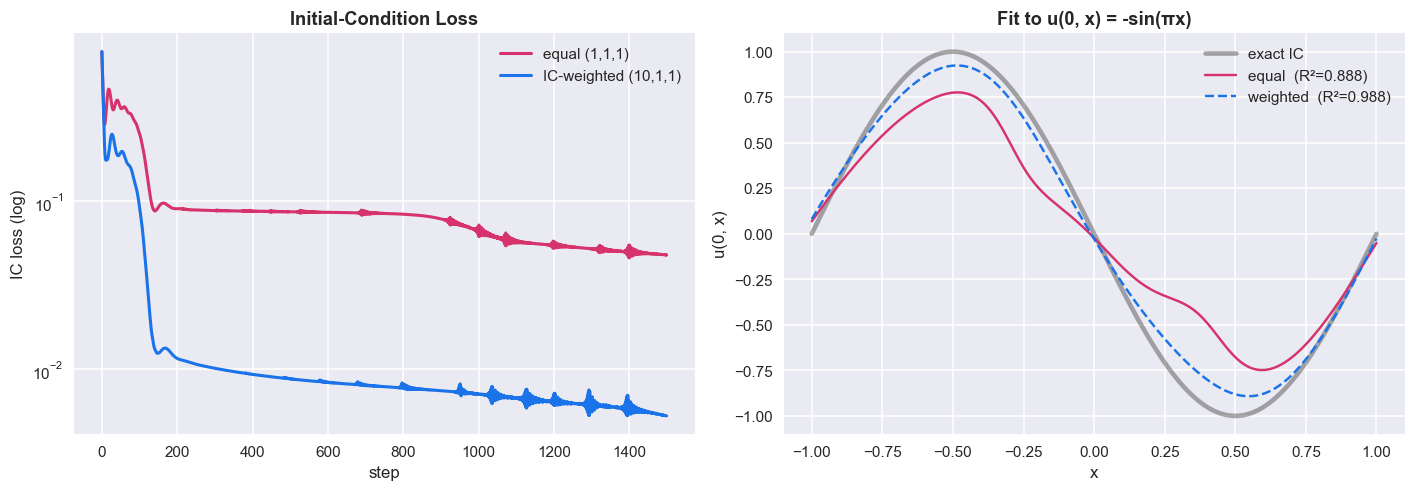

IC fit quality:  equal R² = 0.8881   vs   IC-weighted R² = 0.9879


In [4]:
xe, pe, te, r2e = ic_fit(a)
xw, pw, tw, r2w = ic_fit(b)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(hist_equal["ic"],    color=ACCENT2, lw=2, label="equal (1,1,1)")
a1.plot(hist_weighted["ic"], color=ACCENT,  lw=2, label="IC-weighted (10,1,1)")
a1.set_yscale("log"); a1.set(title="Initial-Condition Loss", xlabel="step", ylabel="IC loss (log)")
a1.legend()

a2.plot(xe, te, color="#111", lw=3, alpha=0.35, label="exact IC")
a2.plot(xe, pe, color=ACCENT2, lw=1.6, label=f"equal  (R²={r2e:.3f})")
a2.plot(xw, pw, color=ACCENT,  lw=1.6, ls="--", label=f"weighted  (R²={r2w:.3f})")
a2.set(title="Fit to u(0, x) = -sin(πx)", xlabel="x", ylabel="u(0, x)"); a2.legend()
plt.tight_layout(); plt.show()

print(f"IC fit quality:  equal R² = {r2e:.4f}   vs   IC-weighted R² = {r2w:.4f}")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Up-weighting the initial condition yields a markedly tighter fit to u(0, x) for the same compute — the optimiser stops neglecting the term that anchors the whole solution in time.
</div>

<a id="takeaways"></a>

## 4 · Takeaways

- **Loss balancing is not optional** in PINNs — unequal-scale terms cause the optimiser to neglect
  the harder-to-minimise ones (often the IC/BC).
- A simple manual up-weight of the initial/boundary terms is a strong, cheap baseline.
- For automatic balancing, the library provides `AdaptiveLossWeighting` and the
  `LossBalancingAnalyzer` in `pinnlab.training` — they tune the weights from gradient statistics during
  training.

### 📚 References

1. Wang, S., Teng, Y., & Perdikaris, P. (2021). *Understanding and mitigating gradient pathologies in PINNs*. SIAM J. Sci. Comput., 43(5), A3055–A3081.
2. McClenny, L., & Braga-Neto, U. (2020). *Self-adaptive PINNs*. arXiv:2009.04544.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>